In [7]:
%pip install streetview osmnx geopandas matplotlib tqdm

Note: you may need to restart the kernel to use updated packages.


In [2]:
import osmnx as ox

name = "Jersey City, New Jersey, United States"
boundary = ox.geocode_to_gdf(name)

boundary["display_name"]

0    Jersey City, Hudson County, New Jersey, United...
Name: display_name, dtype: str

<Axes: >

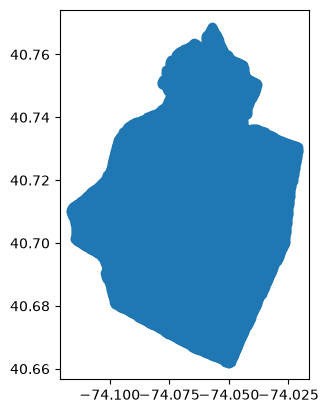

In [13]:
# Sample points every 50 meters within the boundary
import geopandas as gpd
from shapely.geometry import Point

distance = 50  # meters
boundary = boundary.to_crs(epsg=3857)  # Project to meters
minx, miny, maxx, maxy = boundary.total_bounds
points: list[Point] = []
x = minx
while x <= maxx:
    y = miny
    while y <= maxy:
        point = Point(x, y)
        if boundary.contains(point).any():
            points.append(point)
        y += distance
    x += distance
points_gdf = gpd.GeoDataFrame(geometry=points, crs=boundary.crs)
points_gdf = points_gdf.to_crs(epsg=4326)  # Convert back to lat/lon
points_gdf.plot()

In [26]:
import sqlite3
from contextlib import contextmanager

@contextmanager
def get_conn():
    conn = sqlite3.connect('google_maps.db')
    c = conn.cursor()
    try:
        yield conn, c
    finally:
        conn.commit()
        conn.close()

# Connect to SQLite database (or create it if it doesn't exist)
with get_conn() as (conn, c):

    # Create table of searches
    # Maps (lat, lon) to a list of (id, lat, lon, heading, pitch, roll, date)
    c.execute("PRAGMA foreign_keys = ON;")
    c.execute("PRAGMA journal_mode=WAL")
    c.execute("PRAGMA synchronous=NORMAL")

    c.execute('''
        CREATE TABLE IF NOT EXISTS search_locations (
            id INTEGER PRIMARY KEY AUTOINCREMENT,
            lat REAL NOT NULL,
            lon REAL NOT NULL,
            UNIQUE(lat, lon)
        )
    ''')

    c.execute('''
        CREATE TABLE IF NOT EXISTS panoramas (
            id INTEGER PRIMARY KEY AUTOINCREMENT,
            lat REAL NOT NULL,
            lon REAL NOT NULL,
            pano_id TEXT NOT NULL,
            location_id INTEGER NOT NULL,
            heading REAL,
            pitch REAL,
            roll REAL,
            capture_date TEXT,
            FOREIGN KEY (location_id) REFERENCES search_locations(id) ON DELETE CASCADE,
            UNIQUE(pano_id)
        )
    ''')

In [27]:
import time
from concurrent.futures import ThreadPoolExecutor, as_completed
from tqdm import tqdm
from streetview import search_panoramas

MAX_WORKERS = 16     # network-bound; raise until you see rate limiting/errors
COMMIT_EVERY = 50    # batch commits instead of one fsync per point

panoramas_found_by_point = {}

def fetch(key, lat, lon, retries=3):
    # Runs in a worker thread: ONLY network, never touches the DB.
    for attempt in range(retries):
        try:
            return key, lat, lon, search_panoramas(lat, lon), None
        except Exception as e:
            if attempt == retries - 1:
                return key, lat, lon, None, e   # signal failure; don't record it
            time.sleep(2 ** attempt)            # simple backoff

with get_conn() as (conn, c):
    c.execute("""
        SELECT sl.id, sl.lat, sl.lon, COUNT(p.id) AS pano_count
        FROM search_locations sl
        LEFT JOIN panoramas p ON p.location_id = sl.id
        GROUP BY sl.id
    """)
    existing = {(lat, lon): (lid, cnt) for lid, lat, lon, cnt in c.fetchall()}

    total = 0
    new_points = []
    for point in points_gdf.itertuples():
        lat, lon = point.geometry.y, point.geometry.x
        key = (lat, lon)
        if key in existing:
            cnt = existing[key][1]
            panoramas_found_by_point[key] = cnt
            total += cnt
        else:
            new_points.append((key, lat, lon))

    pbar = tqdm(total=len(new_points))
    done = 0
    with ThreadPoolExecutor(max_workers=MAX_WORKERS) as ex:
        futures = [ex.submit(fetch, k, la, lo) for k, la, lo in new_points]
        for fut in as_completed(futures):
            key, lat, lon, panoramas, err = fut.result()
            if err is not None:
                pbar.update(1) 
                continue

            c.execute("INSERT INTO search_locations (lat, lon) VALUES (?, ?)", (lat, lon))
            location_id = c.lastrowid
            for pano in panoramas:
                c.execute("""
                    INSERT OR IGNORE INTO panoramas
                        (pano_id, location_id, lat, lon, heading, pitch, roll, capture_date)
                    VALUES (?, ?, ?, ?, ?, ?, ?, ?)
                """, (pano.pano_id, location_id, lat, lon,
                      pano.heading, pano.pitch, pano.roll, pano.date))

            panoramas_found_by_point[key] = len(panoramas)
            total += len(panoramas)
            done += 1
            if done % COMMIT_EVERY == 0:
                conn.commit()
            pbar.update(1)
            pbar.set_postfix({'count': len(panoramas), 'total': total})

    conn.commit()
    pbar.close()

100%|██████████| 34621/34621 [13:15<00:00, 43.55it/s, count=51, total=765047]  


<Axes: >

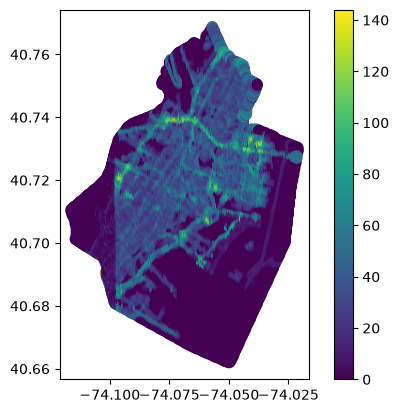

In [28]:
# Plot panoramas found by point
df = gpd.GeoDataFrame(
    [{'geometry': gpd.points_from_xy([lon], [lat])[0], 'count': count} for (lat, lon), count in panoramas_found_by_point.items()],
    crs="EPSG:4326"
)
df.plot(column='count', cmap='viridis', legend=True, markersize=50)